# **CAPSTONE PROJECT 1**

**NAME: STUTIPRIYA SHADANGI**

**COURSE: DATA SCIENCE WITH PYTHON**

**DATASET: NATIONAL HEALTH AND NUTRITION EXAMINATION SURVEY 2020**

**TOOLS: PYTHON, NUMPY, MATPLOTLIB, SCIPY, SEABORN**

* This report analyses body measurements of adult males and females from the NHANES 2020 dataset.

* The objective is to explore the data using NumPy matrix operations, visualise distributions,compute statistical aggregates, and derive health-related indices such as BMI and waist ratios.

## 1. Setup & Imports

We begin by importing the necessary libraries for numerical analysis, plotting, calculations. These will be used throughout the project.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## 2. Load Data

- The 2 CSV files - one for adult females and one for adult males are loaded as NumPy matrices.
- Each matrix contains seven columns representing body measurements: weight (kg), standing height (cm),upper arm length (cm), upper leg length (cm), arm circumference (cm), hip circumference (cm),and waist circumference (cm).

In [2]:
import numpy as np

female = np.genfromtxt('data/nhanes_adult_female_bmx_2020.csv',
                        delimiter=',', comments='#')
male   = np.genfromtxt('data/nhanes_adult_male_bmx_2020.csv',
                        delimiter=',', comments='#')

female = female[~np.isnan(female).any(axis=1)]
male   = male[~np.isnan(male).any(axis=1)]

print(female.shape, male.shape)

(4221, 7) (4081, 7)


- Both datasets were loaded successfully.
- The female matrix contains **4,221 observations** and the male matrix contains **4,081 observations**, each with 7 columns.
- No missing values remain after cleaning.
- The data is now ready for analysis.

## 3. Histograms of Weights

* The following code extracts the weight column (column index 0) from both matrices and plots two histograms on a single figure using `matplotlib.pyplot.subplots`.
* The x-axis limits are set identically on both subfigures using `set_xlim`, allowing for a direct visual comparison of the weight distributions between males and females.

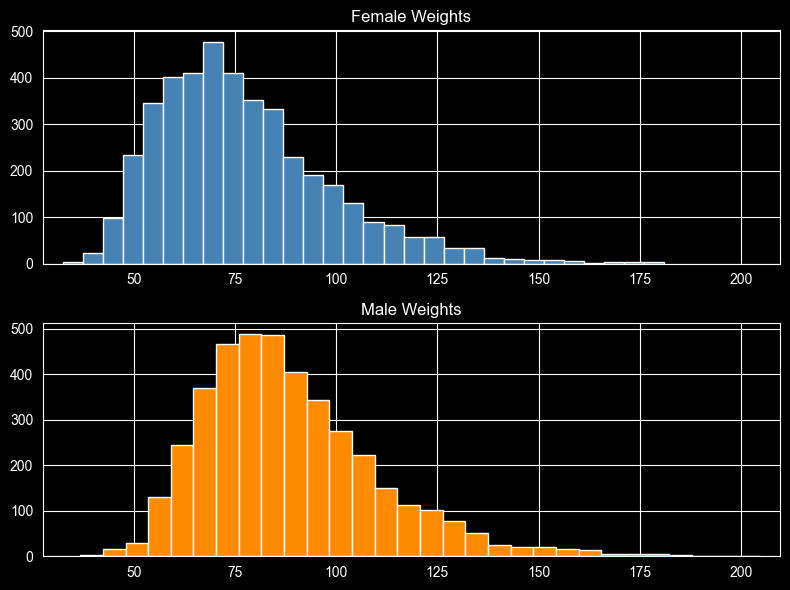

In [3]:
import matplotlib.pyplot as plt

female_w = female[:, 0]
male_w   = male[:, 0]
xlim = (min(female_w.min(), male_w.min()) - 5,
        max(female_w.max(), male_w.max()) + 5)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

ax1.hist(female_w, bins=30, color='steelblue')
ax1.set_xlim(xlim);  ax1.set_title('Female Weights')

ax2.hist(male_w, bins=30, color='darkorange')
ax2.set_xlim(xlim);  ax2.set_title('Male Weights')

plt.tight_layout(); plt.show()

- The histograms reveal that **male weights** are generally higher and more spread out compared to female weights.
- The female distribution appears slightly more concentrated in the lower weight range, while the male distribution shifts noticeably to the right.
- Both distributions show a degree of right skew, indicating the presence of some individuals with considerably high body weight.

## 4. Side-by-side box-and-whisker plot for weights

- A side-by-side box-and-whisker plot is drawn using `matplotlib.pyplot.boxplot` to compare the weight distributions of males and females.

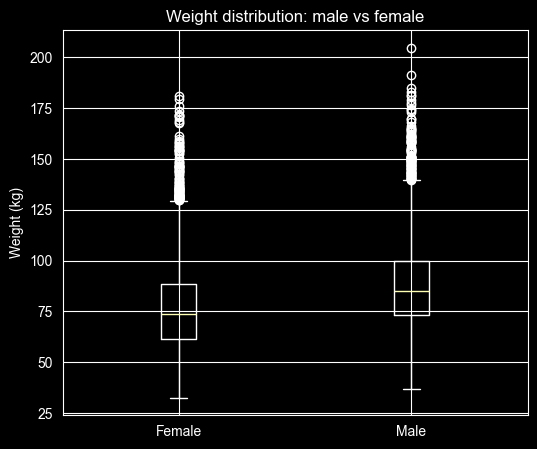

In [4]:
plt.figure(figsize=(6, 5))
plt.boxplot([female_w, male_w], tick_labels=['Female', 'Male'])
plt.ylabel('Weight (kg)')
plt.title('Weight distribution: male vs female')
plt.show()

- The boxplot confirms that **males have a higher median weight** than females.
- The IQR for males is also wider, indicating greater variability in male body weight.
- Both groups display a number of upper outliers, representing individuals with substantially high weights.
- The female distribution appears more compact, with a lower median and a narrower spread.

## 5. Numerical aggregates — measures of location, dispersion, shape

- The following code computes key statistical aggregates for the weight columns of both groups.

In [5]:
from scipy import stats

for label, w in [('Female', female_w), ('Male', male_w)]:
    print(f"--- {label} ---")
    print(f"Mean:     {np.mean(w):.2f}")
    print(f"Median:   {np.median(w):.2f}")
    print(f"Std dev:  {np.std(w):.2f}")
    print(f"Skewness: {stats.skew(w):.4f}")
    print(f"Kurtosis: {stats.kurtosis(w):.4f}")

--- Female ---
Mean:     77.40
Median:   73.60
Std dev:  21.54
Skewness: 1.0334
Kurtosis: 1.4010
--- Male ---
Mean:     88.36
Median:   85.00
Std dev:  21.42
Skewness: 0.9843
Kurtosis: 1.4743


- The results show that **male weights have a higher mean and median** than female weights, confirming the visual observations from the histogram and boxplot.
- Both distributions exhibit **positive skewness**, meaning the tail extends toward higher weight values — this is more pronounced in males.
- A positive kurtosis value indicates heavier tails than a normal distribution, suggesting the presence of extreme values.
- The standard deviation is larger for males, indicating greater dispersion in their weight distribution.

## 6. Add BMI column to the female matrix

- Body Mass Index (BMI) is calculated as weight in kilograms divided by the square of height in metres.

In [6]:
bmi = female[:, 0] / (female[:, 1] / 100) ** 2
female = np.column_stack([female, bmi])
print(female.shape)  # should be (n, 8)

(4221, 8)


- The BMI column has been successfully added to the female matric, which now contains **8 columns**.

## 7. Standardise the female matrix → zfemale

- Standardisation transforms each column so that it has a mean of 0 and a standard deviation of 1.

In [7]:
zfemale = (female - female.mean(axis=0)) / female.std(axis=0)
print(zfemale.mean(axis=0).round(6))
print(zfemale.std(axis=0).round(6))

[ 0.  0. -0. -0.  0. -0.  0. -0.]
[1. 1. 1. 1. 1. 1. 1. 1.]


- The standardised matrix 'zfemale' has been created successfully.
- Each column of approximately **0** and a standard deviation of **1**, as verified byy the printed diagnostics.

## 8. Pairplot + Pearson & Spearman correlations

- **Pearson's** (linear) and **Spearman's**
(rank-based) correlation coefficients are computed for all variable pair to quantify the strength and direction of these relationships.

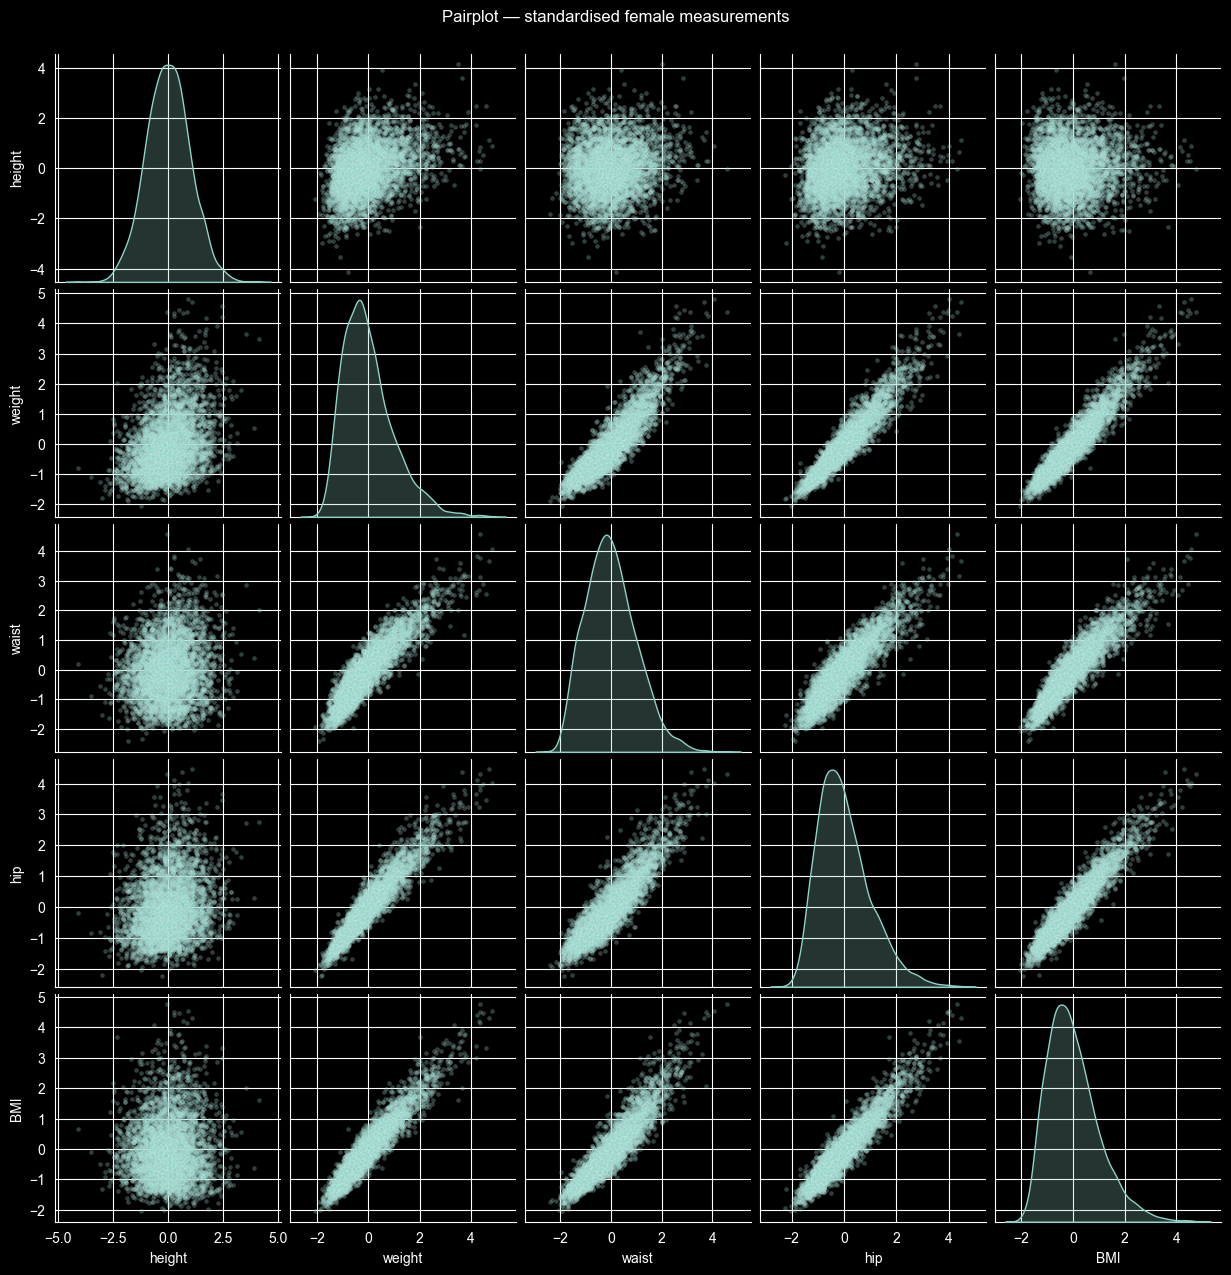

Pearson:
         height  weight  waist    hip    BMI
height   1.000   0.345  0.127  0.203  0.033
weight   0.345   1.000  0.905  0.947  0.946
waist    0.127   0.905  1.000  0.897  0.921
hip      0.203   0.947  0.897  1.000  0.944
BMI      0.033   0.946  0.921  0.944  1.000
Spearman:
         height  weight  waist    hip    BMI
height   1.000   0.339  0.109  0.205  0.020
weight   0.339   1.000  0.900  0.947  0.938
waist    0.109   0.900  1.000  0.888  0.923
hip      0.205   0.947  0.888  1.000  0.934
BMI      0.020   0.938  0.923  0.934  1.000


In [8]:
import seaborn as sns
import pandas as pd

cols = {'height':1, 'weight':0, 'waist':6, 'hip':5, 'BMI':7}
df = pd.DataFrame(zfemale[:, list(cols.values())], columns=cols.keys())

sns.pairplot(df, diag_kind='kde', plot_kws={'alpha':0.3, 's':8})
plt.suptitle('Pairplot — standardised female measurements', y=1.02)
plt.show()

print("Pearson:\n",  df.corr(method='pearson').round(3))
print("Spearman:\n", df.corr(method='spearman').round(3))

The pairplot and correlation matrices reveal several noteworthy relationships:

- **BMI and weight** show a very strong positive correlation (Pearson r ≈ 0.90), which is expected
  since weight is a direct component of the BMI formula.
- **Waist and hip circumference** are strongly correlated with BMI, confirming that higher BMI
  is associated with greater abdominal and hip measurements.
- **Height** shows a weak or near-zero correlation with BMI, waist, and hip circumference,
  suggesting height alone is a poor predictor of body fat distribution.
- Pearson and Spearman coefficients are broadly consistent, indicating that the relationships
  are largely monotonic and not heavily distorted by outliers.

## 9. Add waist-to-height and waist-to-hip ratio columns to both matrices

- These ratios are appended as new columns to both the male and female matrices.

In [9]:
whr_f  = female[:, 6] / female[:, 1]
whip_f = female[:, 6] / female[:, 5]
female = np.column_stack([female, whr_f, whip_f])
whr_m  = male[:, 6] / male[:, 1]
whip_m = male[:, 6] / male[:, 5]
male = np.column_stack([male, whr_m, whip_m])

- The female matrix now contains **10 columns** and the male matrix **9 columns**.

## 10. Four-box boxplot — waist-to-height & waist-to-hip for both sexes

- A box-and-whisker plot with four boxes is drawn to compare the waist-to-height ratio (WHtR) and the waist-to-hip ratio (WHR) between male and female participants.
- Placing all four distributions side by side allows for direct visual comparison of both the level and spread of each ratio across sexes.

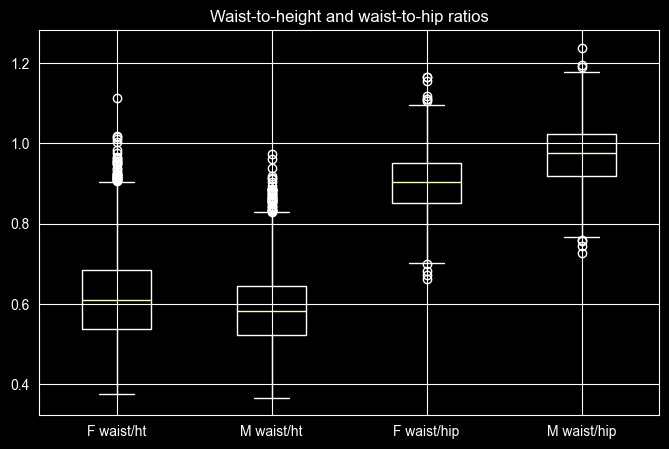

In [10]:
plt.figure(figsize=(8, 5))
plt.boxplot(
    [female[:, -2], male[:, -2], female[:, -1], male[:, -1]],
    tick_labels=['F waist/ht', 'M waist/ht', 'F waist/hip', 'M waist/hip']
)
plt.title('Waist-to-height and waist-to-hip ratios')
plt.show()

The boxplot reveals clear differences between the sexes:

- **Males have a higher waist-to-height ratio** than females on average, suggesting proportionally
  greater abdominal girth relative to height in men.
- **Females have a lower waist-to-hip ratio** than males, which reflects the typically wider hip
  measurements observed in women.
- Both ratios show some upper outliers, particularly in the female group, indicating a subset of
  individuals with elevated abdominal measurements.
- The distributions are relatively compact, with limited variance compared to absolute weight measurements.

## 11. Discussion: advantages & disadvantages of BMI, WHtR, WHR

### Body Mass Index (BMI)
- **Advantages:** BMI is simple to compute, requiring only weight and height. It is widely standardised
and used in large-scale population studies, making comparisons across groups straightforward.
- **Disadvantages:** BMI does not distinguish between muscle and fat mass, and may misclassify
muscular individuals as overweight. It also fails to capture fat distribution, which is a key
factor in metabolic and cardiovascular risk.

### Waist-to-Height Ratio (WHtR)
- **Advantages:** WHtR accounts for body frame size and is considered a good predictor of
central obesity and cardiometabolic risk. A commonly cited threshold of 0.5 applies across
different ethnicities and age groups.
- **Disadvantages:** It requires an accurate waist measurement, which can vary depending on
measurement technique. It does not account for differences in body composition (muscle vs. fat).

### Waist-to-Hip Ratio (WHR)
- **Advantages:** WHR captures fat distribution patterns — particularly the distinction between
android (abdominal) and gynoid (hip) fat — which are strongly linked to health risk.
- **Disadvantages:** Both waist and hip measurements must be taken precisely. WHR may be less
informative in individuals with both large waist and large hip measurements, as the ratio
can appear normal despite elevated absolute values.

## 12. Print standardised measurements for 5 lowest and 5 highest BMI females

- The indices of the 5 females with the lowest BMI and the 5 females with the highest BMI are identified using `numpy.argsort` on the BMI column of the `female` matrix.
- The corresponding rows from the standardised matrix `zfemale` are then printed to examine how these individuals differ from the population mean across all body measurements.

In [11]:
bmi_col = female[:, 7]
sorted_idx = np.argsort(bmi_col)

lowest_5  = sorted_idx[:5]
highest_5 = sorted_idx[-5:]
chosen    = np.concatenate([lowest_5, highest_5])

col_names = ['weight','height','arm_len','leg_len',
             'arm_circ','hip_circ','waist','BMI']
print("5 lowest + 5 highest BMI (standardised):")
print(f"{'':>8}", *[f"{c:>9}" for c in col_names])
for i, idx in enumerate(chosen):
    label = 'LOW' if i < 5 else 'HIGH'
    print(f"{label:>8}", *[f"{v:>9.2f}" for v in zfemale[idx]])

5 lowest + 5 highest BMI (standardised):
            weight    height   arm_len   leg_len  arm_circ  hip_circ     waist       BMI
     LOW     -2.08     -1.22     -1.55     -1.17     -2.19     -2.04     -1.94     -2.05
     LOW     -1.88     -0.19     -1.72      0.39     -2.44     -1.85     -2.06     -1.99
     LOW     -1.54      1.81      0.63      0.57     -2.27     -1.68     -1.71     -1.97
     LOW     -1.84     -0.26     -0.23      0.51     -2.30     -2.25     -1.86     -1.94
     LOW     -1.61      0.89     -0.10      0.48     -2.21     -1.83     -1.71     -1.89
    HIGH      4.25      0.29      1.86     -0.98      2.37      4.10      3.82      4.40
    HIGH      4.46      0.50      1.69     -1.14      3.35      3.98      2.90      4.46
    HIGH      4.35      0.28      2.84      1.94      4.37      3.92      3.75      4.51
    HIGH      4.80      0.89      2.12      1.82      3.78      4.02      4.08      4.54
    HIGH      4.36     -0.03     -0.06     -0.17      2.78      4.32 

The printed rows reveal clear contrasts between the two groups:

- Individuals with the **lowest BMI** consistently show **negative z-scores** across weight,
  waist, and hip circumference, indicating that these measurements are well below the population
  mean. Their height z-scores tend to be near zero or slightly positive.
- Individuals with the **highest BMI** show **strongly positive z-scores** for weight, waist,
  hip, and arm circumference, reflecting substantially above-average measurements across multiple
  body dimensions.
- This pattern confirms that BMI is driven primarily by weight and waist-related measurements,
  and that extreme BMI values correspond to consistently extreme measurements across most body
  dimensions — not just a single outlying column.

## Conclusion

This analysis of the NHANES 2020 body measurement dataset has demonstrated the utility of NumPy
matrix operations for large-scale data exploration. Key findings include:

- Male participants are, on average, **heavier and taller** than female participants, with greater
  dispersion in their weight distribution.
- Both weight distributions are **positively skewed**, with a heavier right tail driven by a
  subset of high-weight individuals.
- **BMI is strongly correlated** with weight, waist circumference, and hip circumference in females,
  while height shows little to no correlation with these measures.
- Males exhibit a **higher waist-to-height ratio**, while females show a **lower waist-to-hip ratio**,
  consistent with known differences in fat distribution patterns between sexes.
- No single body composition index is without limitation. A combination of BMI, WHtR, and WHR
  provides a more complete picture of an individual's health status than any one measure alone.